#### Importing necessary libraries

In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import shap

d:\10Pearls\pearls_aqi_predictor\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load dataset
df = pd.read_csv("../data/processed/featured_aqi_data.csv")

# Features and target
features = [
    "temperature", "humidity", "wind_speed", "pressure",
    "pm25", "pm10", "co", "no2", "o3",
    "hour", "day", "month", "day_of_week","is_weekend", "is_rush_hour",
    "previous_aqi", "aqi_lag_3", "aqi_lag_6", "aqi_lag_12",
    "rolling_avg_3", "rolling_avg_6","rolling_avg_24", "aqi_change","aqi_trend", "pollution_index"
]
target = "future_aqi"

#### Train-test split

In [3]:

split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df  = df.iloc[split_index:]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]


#### model loading and predictions

In [4]:
# Load best model
model = joblib.load("../models/best_aqi_model.pkl")

# Predictions
predictions = model.predict(X_test)

#### PREDICTION VS ACTUAL

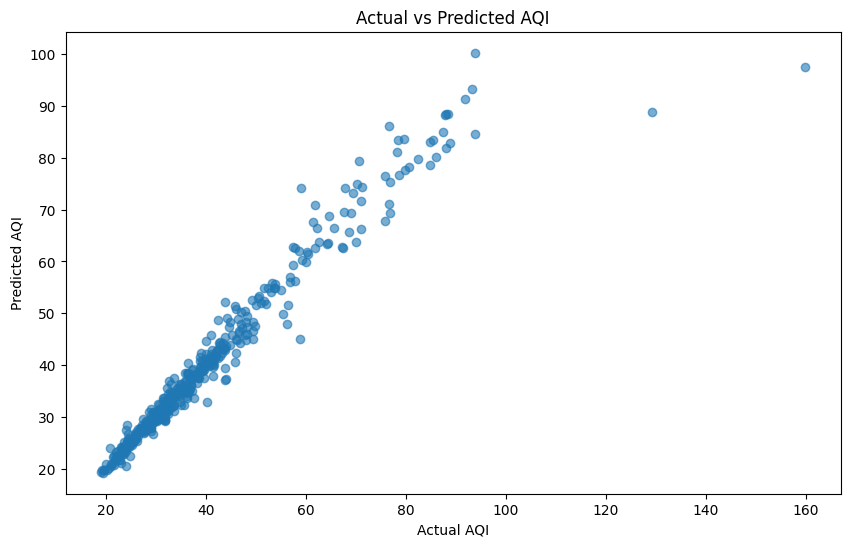

In [5]:
plt.figure(figsize=(10,6))

plt.scatter(
    y_test,
    predictions,
    alpha=0.6
)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")

plt.title("Actual vs Predicted AQI")

plt.show()

##### RESIDUAL ANALYSIS

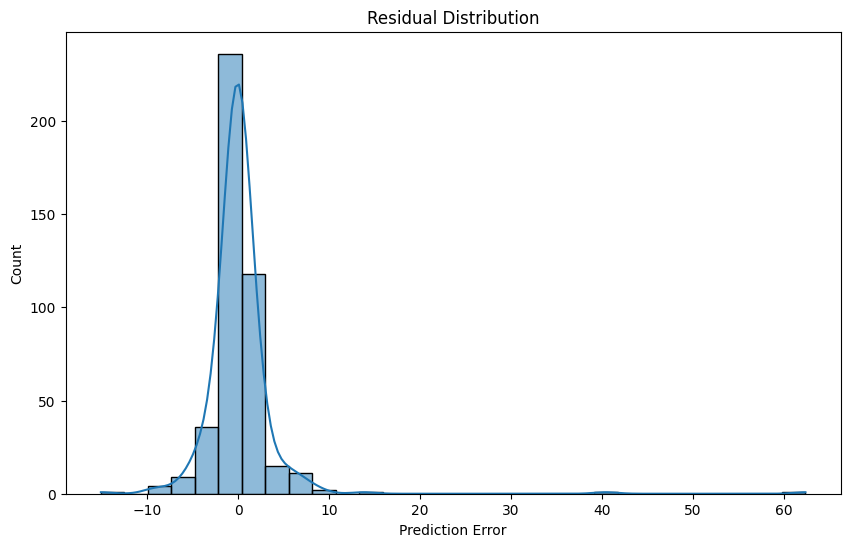

In [6]:
residuals = y_test - predictions

plt.figure(figsize=(10,6))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.title("Residual Distribution")

plt.xlabel("Prediction Error")

plt.show()

#### FEATURE IMPORTANCE

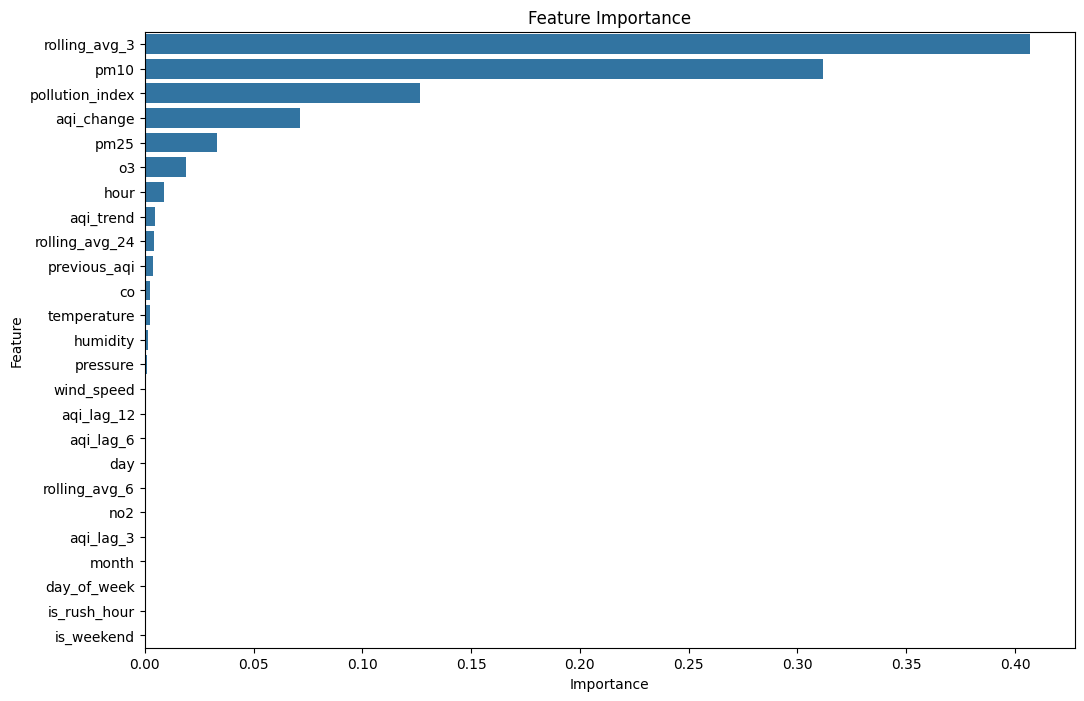

,Feature,Importance
19,rolling_avg_3,0.407093
5,pm10,0.311696
24,pollution_index,0.126349
22,aqi_change,0.071355
4,pm25,0.032967
8,o3,0.018767
9,hour,0.008636
23,aqi_trend,0.004714
21,rolling_avg_24,0.004244
15,previous_aqi,0.003821


In [7]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(12,8))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance")

plt.show()

feature_importance.head(10)

# SHAP EXPLAINABILITY

In [8]:
# Create SHAP explainer
explainer = shap.Explainer(model, X_train)

# Compute SHAP values
shap_values = explainer(X_test,check_additivity=False)

##### SHAP SUMMARY PLOT

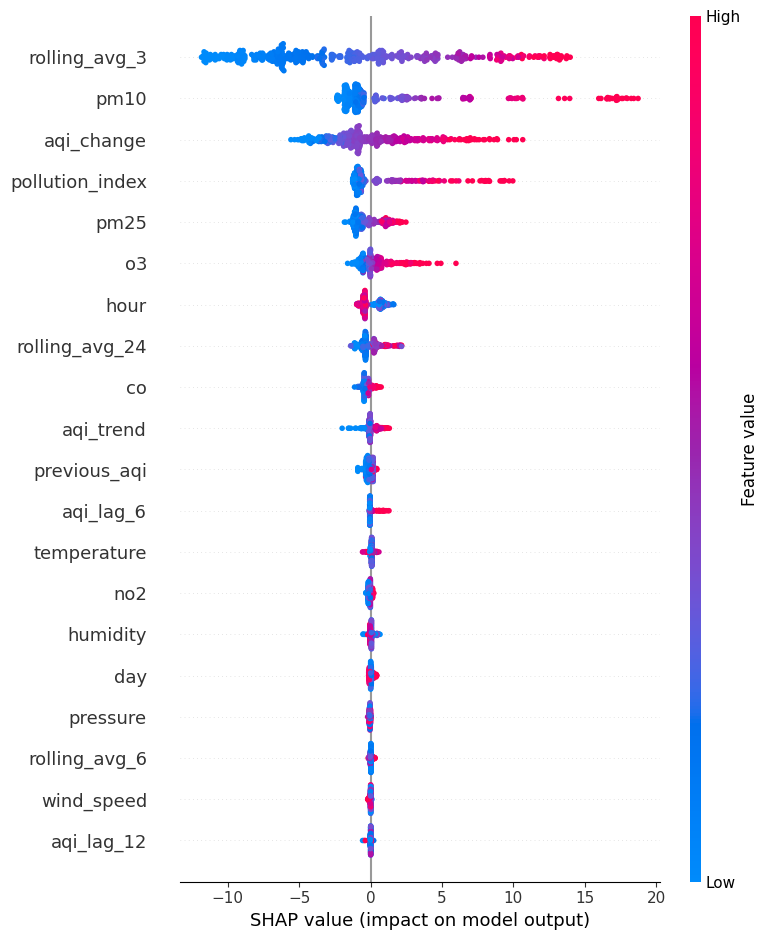

In [9]:
shap.summary_plot(
    shap_values,
    X_test
)